# California Housing — Análise e Modelagem

Notebook com EDA, preparação dos dados e comparação de 5 modelos de regressão.

> **Aviso**: este notebook simula um notebook desenvolvido por um Cientista de Dados, ele será usado como ponto de partida para a refatoração feita em `src/ml_pipeline/`.

In [10]:
import pickle
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
%matplotlib inline

## 1. Carregamento

In [11]:
data = fetch_california_housing(as_frame=True)
df = data.frame
print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. EDA

In [12]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [13]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

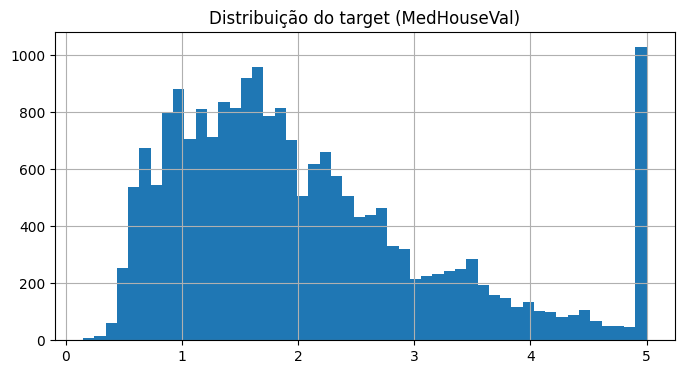

In [14]:
df["MedHouseVal"].hist(bins=50, figsize=(8, 4))
plt.title("Distribuição do target (MedHouseVal)")
plt.show()

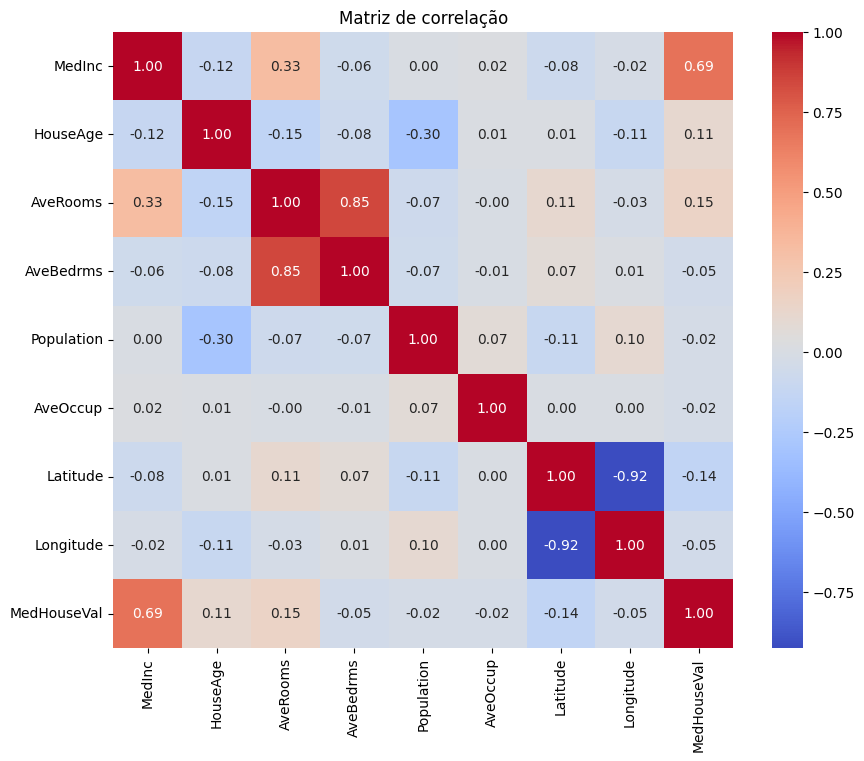

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
plt.title("Matriz de correlação")
plt.show()

## 3. Pré-processamento, features, treino e avaliação

Tudo em uma única célula. Anti-pattern intencional:
- violação de SRP
- magic numbers
- leakage de scaler antes do split
- `print` em vez de logging
- sem type hints
- sem validação de schema

In [16]:
df = df[df["MedHouseVal"] < 5.0]  # remove "capping" do target
df["rooms_per_household"] = df["AveRooms"] / df["HouseAge"].replace(0, 1)
df["bedrooms_per_room"] = df["AveBedrms"] / df["AveRooms"]
df["population_per_household"] = df["Population"] / df["AveOccup"]

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # RED FLAG: fit antes do split gera leakage

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
}

results = []
for name, m in models.items():
    t0 = time.time()
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name}: RMSE={rmse:.4f} MAE={mae:.4f} R2={r2:.4f} ({time.time()-t0:.1f}s)")
    results.append({"model": name, "rmse": rmse, "mae": mae, "r2": r2})

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df

LinearRegression: RMSE=0.6081 MAE=0.4526 R2=0.6143 (0.1s)
Ridge: RMSE=0.6081 MAE=0.4526 R2=0.6143 (0.0s)
Lasso: RMSE=0.6081 MAE=0.4529 R2=0.6143 (0.5s)
RandomForest: RMSE=0.4678 MAE=0.3141 R2=0.7718 (8.8s)
GradientBoosting: RMSE=0.4656 MAE=0.3252 R2=0.7739 (10.5s)


,model,rmse,mae,r2
0,GradientBoosting,0.465585,0.325244,0.773899
1,RandomForest,0.467777,0.314066,0.771765
2,LinearRegression,0.608061,0.452558,0.614345
3,Ridge,0.608065,0.452562,0.614340
4,Lasso,0.608110,0.452891,0.614283


## 4. Persistência do melhor modelo

In [17]:
best_name = results_df.iloc[0]["model"]
best = models[best_name]

with open("best_model.pkl", "wb") as f:  # path hardcoded, sem versionamento
    pickle.dump(best, f)
print("salvo:", best_name)

salvo: GradientBoosting


## 5. Dependências

In [18]:
#!pip freeze > requirements.txt